In [1]:
#package dependencies and suppress unnecessary warning messages 
from numba.core.errors import NumbaDeprecationWarning, NumbaPendingDeprecationWarning, NumbaWarning
import warnings

warnings.simplefilter('ignore', category=NumbaDeprecationWarning)
warnings.simplefilter('ignore', category=NumbaPendingDeprecationWarning)
warnings.simplefilter('ignore', category=NumbaWarning)

In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import zipfile


In [3]:
adata = sc.read_h5ad("./e12_full_norm.h5ad")


In [5]:
# Keep an object with only raw counts
adata_raw_counts = adata.copy()

In [6]:
batch_key = 'sample_name'

In [7]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()

In [8]:
s_genes = [
"Mcm5","Pcna","Tyms","Fen1","Mcm2","Mcm4","Rrm1","Ung","Gins2","Mcm6",
"Cdca7","Dtl","Prim1","Uhrf1","Mlf1ip","Hells","Rfc2","Rpa2","Nasp",
"Rad51ap1","Gmnn","Wdr76","Slbp","Ccne2","Ubr7","Pold3","Msh2","Atad2",
"Rad51","Rrm2","Cdc45","Cdc6","Exo1","Tipin","Dscc1","Blm","Casp8ap2",
"Usp1","Clspn","Pola1","Chaf1b","Brip1","E2f8","Hmgb2"
]
len(s_genes)


44

In [9]:
g2m_genes = [
"Cdk1","Nusap1","Ube2c","Birc5","Tpx2","Top2a","Ndc80","Cks2","Nuf2",
"Cks1b","Mki67","Tmpo","Cenpf","Tacc3","Fam64a","Smc4","CcnB2",
"Ckap2l","Ckap2","Aurkb","Bub1","Kif11","Anp32e","Tubb4b","Gtse1",
"Kif20b","Hjurp","Cdca3","Hn1","Cdc20","Ttk","Cdc25c","Kif2c",
"Rangap1","Ncapd2","Dlgap5","Cdca2","Cdca8","Ect2","Kif23","Hmmr",
"Aurka","Psrc1","Anln","Lbr","Ckap5","Cenpe","Ctcf","Nek2",
"G2e3","Gas2l3","Cbx5","Cenpa"
]
len(g2m_genes)

53

In [10]:

s_genes = [g for g in s_genes if g in adata.var_names]
g2m_genes = [g for g in g2m_genes if g in adata.var_names]


cell_cycle_genes = [*s_genes, *g2m_genes]
len(cell_cycle_genes)


93

In [11]:
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

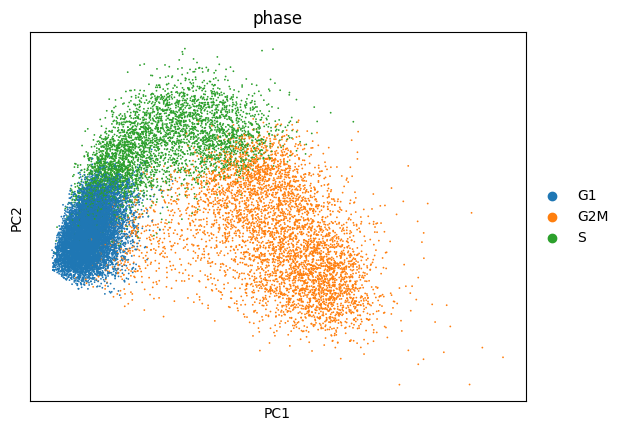

In [12]:
adata_cc_genes = adata[:, cell_cycle_genes].copy()

adata_cc_genes
sc.tl.pca(adata_cc_genes)
sc.pl.pca_scatter(adata_cc_genes, color="phase")

In [13]:
sc.pp.regress_out(adata, ["S_score", "G2M_score"])

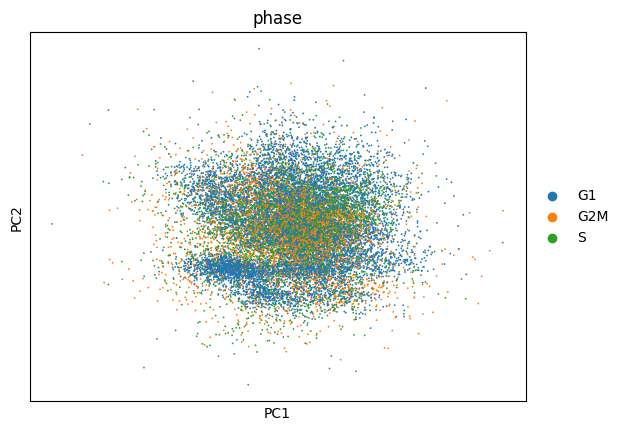

In [14]:
adata_cc_genes = adata[:, cell_cycle_genes].copy()
sc.tl.pca(adata_cc_genes)
sc.pl.pca_scatter(adata_cc_genes, color="phase")

In [19]:
adata

AnnData object with n_obs × n_vars = 18203 × 26225
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet', 'sample_id', 'sample_name', 'sample_group', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'gene_name', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'sample_name_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [32]:
adata.var

,gene_ids,gene_name,mt,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
0610005C13Rik,ENSMUSG00000109644,0610005C13Rik,False,False,0.000117,-3.105473,-0.629394,0,False
0610006L08Rik,ENSMUSG00000108652,0610006L08Rik,False,False,0.000024,0.221908,-1372.019897,0,False
0610009B22Rik,ENSMUSG00000007777,Trappc2b,False,False,0.000502,-0.572286,0.105023,0,False
0610009E02Rik,ENSMUSG00000086714,0610009E02Rik,False,False,-0.000265,7.786786,0.948651,0,False
0610009L18Rik,ENSMUSG00000043644,0610009L18Rik,False,False,0.000048,-2.004124,-0.182150,0,False
...,...,...,...,...,...,...,...,...,...
mt-Nd3,ENSMUSG00000064360,mt-Nd3,True,False,0.016219,4.399645,1.306346,1,False
mt-Nd4,ENSMUSG00000064363,mt-Nd4,True,False,0.010788,-5.153970,-1.222398,0,False
mt-Nd4l,ENSMUSG00000065947,mt-Nd4l,True,False,0.009904,12.624091,1.375901,1,False
mt-Nd5,ENSMUSG00000064367,mt-Nd5,True,False,0.004520,-2.794882,-0.238836,0,False


In [15]:
sc.pp.highly_variable_genes(adata, flavor='seurat')

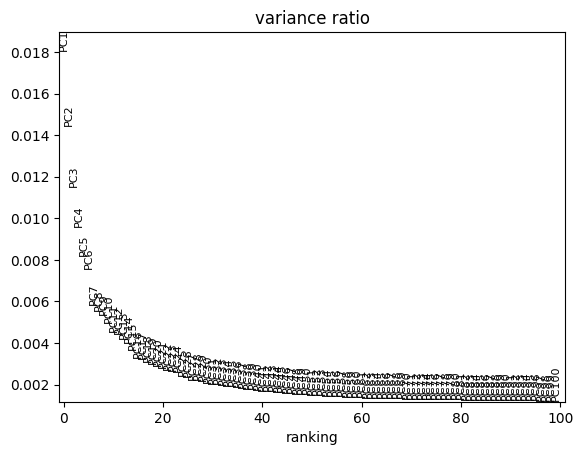

In [16]:
sc.tl.pca(adata, n_comps=100)
sc.pl.pca_variance_ratio(adata, n_pcs=100, log=False, show=None, save=None)

In [17]:
sc.pp.neighbors(adata, n_pcs=50)
sc.tl.umap(adata)


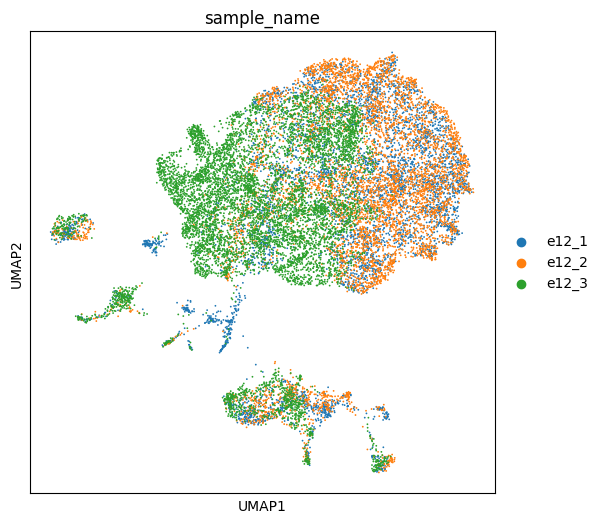

In [18]:
matplotlib.rcParams['figure.figsize'] = [6, 6]
sc.pl.umap(adata, color="sample_name", wspace=1, ncols=1)

In [20]:
#sembra ci sia batch effect 
#seleziono HVGs in modo batch aware aggiungendo batch_key
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="cell_ranger", batch_key=batch_key
)

In [21]:
adata

AnnData object with n_obs × n_vars = 18203 × 26225
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'counts_outlier', 'genes_outlier', 'topgenes_outlier', 'mito_outlier', 'outlier', 'doublet_score', 'predicted_doublet', 'sample_id', 'sample_name', 'sample_group', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'gene_name', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'sample_name_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

highly_variable_nbatches
0    20928
1     4594
2      703
Name: count, dtype: int64

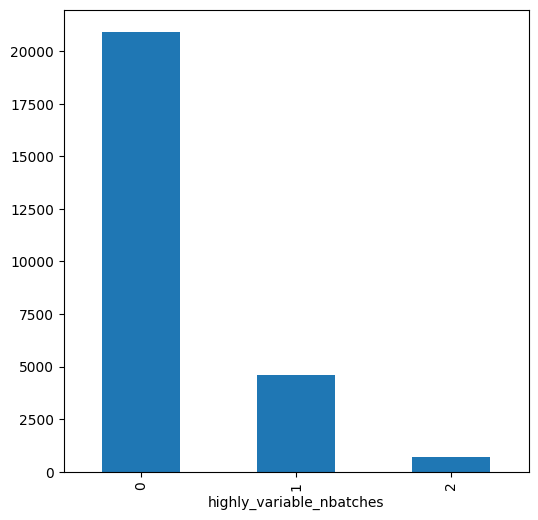

In [22]:
n_batches = adata.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

In [23]:
# move the unintegrated umap
adata.obsm['X_umapraw'] = adata.obsm['X_umap']

In [24]:
adata.obsm['X_umapraw']

array([[ 6.8031354 , 14.57776   ],
       [16.581121  , 13.356728  ],
       [10.392127  , -0.648483  ],
       ...,
       [ 5.793138  , -0.74987525],
       [12.202256  , 13.271578  ],
       [11.860882  , 13.307305  ]], shape=(18203, 2), dtype=float32)

In [20]:
# run harmony via scanpy external API --> buggato
#sc.external.pp.harmony_integrate(adata, key=batch_key, basis = 'X_pca')

In [ ]:
#pare ci sia un bug tra versioni di scanpy e harmonypy percui la chiamata diretta di harmonypy non funzia
# work around è chiamare harmonypy a parte

In [25]:
from harmonypy import run_harmony

In [26]:

z = np.asarray(adata.obsm["X_pca"])
meta = pd.DataFrame({batch_key: adata.obs[batch_key].tolist()})

harmony_out = run_harmony(z, meta, batch_key)

adata.obsm["X_pca_harmony"] = harmony_out.Z_corr   # forma corretta (32650,100)


2026-05-07 13:15:46,969 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-07 13:15:46,970 - harmonypy - INFO -   Parameters:
2026-05-07 13:15:46,971 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-07 13:15:46,971 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-07 13:15:46,972 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-07 13:15:46,972 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-07 13:15:46,972 - harmonypy - INFO -     nclust: 100
2026-05-07 13:15:46,972 - harmonypy - INFO -     block_size: 0.05
2026-05-07 13:15:46,973 - harmonypy - INFO -     lamb: [1. 1. 1.]
2026-05-07 13:15:46,973 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-05-07 13:15:46,974 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-07 13:15:46,974 - harmonypy - INFO -     verbose: True
2026-05-07 13:15:46,974 - harmonypy - INFO -     random_state: 0
2026-05-07 13:15:46,974 - harmonypy - INFO -   Data: 100 PCs × 18203 cells
2026-05-07 13:15:46,975 - harmonyp

In [27]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)


In [28]:
matplotlib.rcParams['figure.figsize'] = [5, 6]

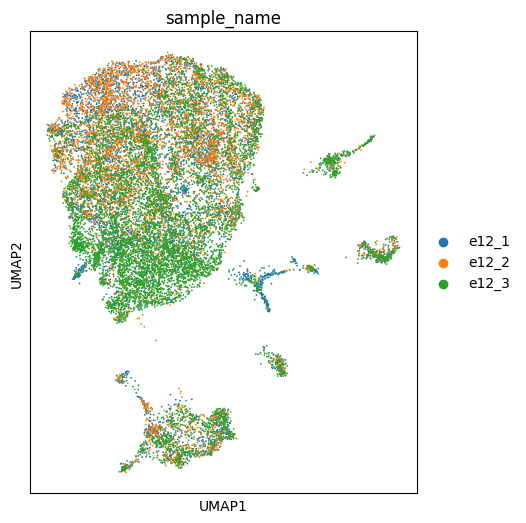

In [29]:
sc.pl.umap(adata, color=[batch_key], ncols=1)

In [30]:
adata.write_h5ad("./e12_full_integrated_regressed.h5ad")